# Module 3 Resilience Indicators

> **Governance status of this notebook**
>
> Runs on **public federal data only**, at **PUBLIC tier**, under no data-use
> agreement. That is a deliberate default: see Module 4.
>
> Federal data being public makes it legally available. It does not make an
> *analysis about a Nation* publishable by default: the aggregate product is a
> new artifact, and releasing it is a governance decision that source licensing
> does not settle. `ctx.check_publication()` blocks until sign-off is recorded.
>
> Set `NATION` and `REGION_NAME` below to retarget.

## The position this module takes

Standard social vulnerability indices from CDC SVI, SoVI, and descendants perform
badly on Tribal communities, and not incidentally.

They are built from census variables that encode a deficit frame: poverty rate,
unemployment, no vehicle, limited English, single-parent households, mobile
homes. Applied to a reservation they reliably produce a high score and explain
very little, because:

- They measure distance from a white suburban norm, not capacity to withstand
  and recover from fire.
- They miss the actual sources of resilience which consist of kinship networks that mobilize
  faster than any agency, Tribal government emergency authority, land-based
  knowledge, cultural continuity, and in many Nations a fire program with deeper
  local knowledge than the agencies around it.
- Census undercount on reservations is severe and well documented, so the input
  data is weakest exactly where the index is applied most confidently.
- A high vulnerability score is then used to justify external intervention. The
  measurement instrument becomes a political one.

The alternative built here is **asset-based**: it measures capacity that exists.
And it **refuses to run with analyst-chosen weights**, because deciding what
resilience means for a community that was not asked is the same error in a
different coat.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from daear_toolkit import sovereignty as sv
from daear_toolkit import tribal_indicators as ti

NATION = "Oglala Sioux Tribe"
ctx = sv.GovernanceContext(nation=NATION)

print("What a standard SVI would measure:\n")
for v in ti.STANDARD_SVI_VARIABLES:
    print(f"   - {v}")
print("\nEvery one is an absence. None of them is wrong as a fact; together they")
print("compose a description in which the community appears only as a set of deficits.")

What a standard SVI would measure:

   - below poverty line
   - unemployed
   - no high school diploma
   - aged 65+
   - aged 17 or younger
   - with a disability
   - single-parent household
   - speaks English less than well
   - mobile homes
   - crowded housing
   - no vehicle available
   - group quarters

Every one is an absence. None of them is wrong as a fact; together they
compose a description in which the community appears only as a set of deficits.


In [2]:
print("What the asset-based framing measures instead:\n")
for name, desc in ti.ADAPTIVE_CAPACITY_COMPONENTS.items():
    print(f"   {name}")
    print(f"      {desc}\n")

print("Note what these have in common: not one is remotely sensed. A satellite cannot")
print("see mutual-aid agreements or kinship networks. Which is precisely why the next")
print("cell refuses to let an analyst assign them numbers from a desk.")

What the asset-based framing measures instead:

   tribal_fire_program_capacity
      Staffing, equipment, and qualifications held by the Nation's own fire program

   mutual_aid_agreements
      Pre-negotiated agreements with adjacent jurisdictions, reducing authorization delay

   land_based_knowledge
      Active knowledge of fire behaviour, fuels, and terrain held in the community

   cultural_burning_practice
      Existing or revivable cultural burning practice and the authority to exercise it

   kinship_response_networks
      Informal networks that mobilize evacuation and sheltering faster than agencies

   governance_continuity
      Stable Tribal emergency management authority and continuity of program staff

   communications_reach
      Ability to reach households quickly, including where cell coverage is absent

   youth_workforce_pipeline
      Local pathways into fire and natural-resource careers

Note what these have in common: not one is remotely sensed. A satellite c

## Components require sources

Every component here is something only the community can assess. An analyst
assigning them values has invented data and given it the same visual weight as a
measured layer and in a figure, invented numbers and measured numbers look
identical.

`adaptive_capacity` requires a source for each component and raises without
one.

In [3]:
try:
    ti.adaptive_capacity({"tribal_fire_program_capacity": 0.8, "kinship_response_networks": 0.9})
except ValueError as e:
    print("REFUSED:\n")
    print(e)

REFUSED:

Component 'tribal_fire_program_capacity' has no source. These components are community assessments, not remotely sensed quantities -- record who provided the score and when. Pass require_source=False only for a structural example with clearly fabricated values.


In [4]:
# Structural example only. Every value below is FABRICATED to demonstrate the
# mechanics -- none of it represents any assessment by the Oglala Sioux Tribe or
# any other Nation, and it must not be presented as such.
components = ti.adaptive_capacity({
    "tribal_fire_program_capacity": (0.70, "FABRICATED structural example only"),
    "mutual_aid_agreements":        (0.55, "FABRICATED structural example only"),
    "land_based_knowledge":         (0.90, "FABRICATED structural example only"),
    "cultural_burning_practice":    (0.45, "FABRICATED structural example only"),
    "kinship_response_networks":    (0.88, "FABRICATED structural example only"),
    "governance_continuity":        (0.75, "FABRICATED structural example only"),
    "communications_reach":         (0.50, "FABRICATED structural example only"),
    "youth_workforce_pipeline":     (0.60, "FABRICATED structural example only"),
})
components[["component", "score", "source"]]

,component,score,source
0,tribal_fire_program_capacity,0.70,FABRICATED structural example only
1,mutual_aid_agreements,0.55,FABRICATED structural example only
2,land_based_knowledge,0.90,FABRICATED structural example only
3,cultural_burning_practice,0.45,FABRICATED structural example only
4,kinship_response_networks,0.88,FABRICATED structural example only
5,governance_continuity,0.75,FABRICATED structural example only
6,communications_reach,0.50,FABRICATED structural example only
7,youth_workforce_pipeline,0.60,FABRICATED structural example only


## The index refuses analyst-chosen weights

Weights determine what "resilience" means in the output. That determination is a
sovereignty question.

Equal weighting is not a neutral escape. It asserts that every component matters
identically, which is a substantive position and one no community has actually
held.

In [5]:
try:
    ti.community_weighted_index(components)
except ValueError as e:
    print("REFUSED:\n")
    print(e)

REFUSED:

community_weighted_index requires both `weights` and `weights_source`.

Weights determine what 'resilience' means in the output. That determination belongs to the community, not the analyst, and equal weighting is a position rather than a neutral default.

Until weights have been set with the community, present the components separately -- an unaggregated component table is honest and still useful. Once they have been set, pass them with a source:
    community_weighted_index(components, weights={...},
                             weights_source='Tribal fire program workshop, <date>')


Capacity index: 0.6967
Weights source: FABRICATED structural example: NOT a community determination



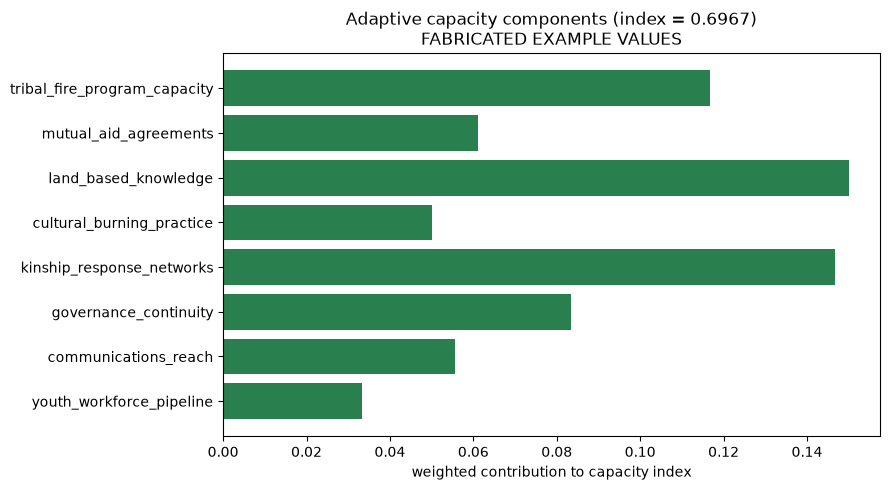

In [6]:
# With weights that have a stated source, the index computes. The source string
# is carried into the output so it travels with any figure derived from it.
result = ti.community_weighted_index(
    components,
    weights={
        "tribal_fire_program_capacity": 3, "mutual_aid_agreements": 2,
        "land_based_knowledge": 3, "cultural_burning_practice": 2,
        "kinship_response_networks": 3, "governance_continuity": 2,
        "communications_reach": 2, "youth_workforce_pipeline": 1,
    },
    weights_source="FABRICATED structural example: NOT a community determination",
)

print(f"Capacity index: {result['index']}")
print(f"Weights source: {result['weights_source']}\n")

contrib = pd.DataFrame(result["components"])
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(contrib["component"], contrib["contribution"], color="#2a7f4f")
ax.set_xlabel("weighted contribution to capacity index")
ax.set_title(f"Adaptive capacity components (index = {result['index']})\nFABRICATED EXAMPLE VALUES")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/03_adaptive_capacity.png", dpi=150)
plt.show()

contrib.to_csv("../outputs/03_capacity_components.csv", index=False)

## How sensitive is this to the weights?

The same Monte Carlo used in `climate-resilience-indicators` Module 3 applies
directly, and here it does something more pointed than usual.

If the index is highly sensitive to weights, then whoever sets the weights is
effectively setting the answer which converts the abstract argument about
authority into a measured quantity. That is a stronger case for community
weighting than any amount of principle.

Across 5,000 weightings drawn uniformly from the weight simplex:
  index range:     0.498 to 0.832
  5th-95th pct:    0.581 to 0.756
  chosen weights:  0.697


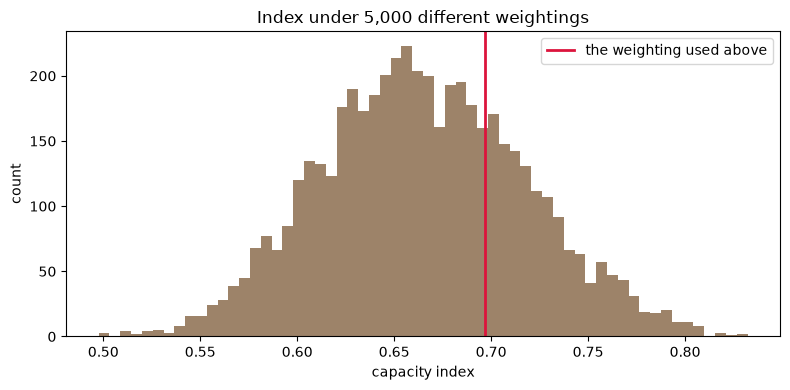


90% of the weight space spans 0.176 index units.
Whoever chooses the weights moves the answer by roughly that much. That is the
measured version of the argument that the choice belongs to the community.


In [7]:
from daear_toolkit import climate_indicators as ci

# Treat each component as a column so the existing sensitivity machinery applies.
as_table = pd.DataFrame([components.set_index("component")["score"]])
as_table.index = ["this_community"]

rng = np.random.default_rng(0)
scores = []
for w in rng.dirichlet(np.ones(len(components)), size=5000):
    scores.append(float((components["score"].values * w).sum()))
scores = np.array(scores)

print(f"Across 5,000 weightings drawn uniformly from the weight simplex:")
print(f"  index range:     {scores.min():.3f} to {scores.max():.3f}")
print(f"  5th-95th pct:    {np.percentile(scores, 5):.3f} to {np.percentile(scores, 95):.3f}")
print(f"  chosen weights:  {result['index']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=60, color="#8c6d4f", alpha=0.85)
ax.axvline(result["index"], color="crimson", lw=2, label="the weighting used above")
ax.set_xlabel("capacity index"); ax.set_ylabel("count")
ax.set_title("Index under 5,000 different weightings")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/03_weight_sensitivity.png", dpi=150)
plt.show()

spread = np.percentile(scores, 95) - np.percentile(scores, 5)
print(f"\n90% of the weight space spans {spread:.3f} index units.")
print("Whoever chooses the weights moves the answer by roughly that much. That is the")
print("measured version of the argument that the choice belongs to the community.")

## The two framings side by side

In [8]:
# Illustrative SVI value for contrast and not computed here, and deliberately not,
# since computing one would require exactly the census variables this module argues
# against using for this purpose.
ILLUSTRATIVE_SVI = 0.92

print(ti.compare_framings(svi_score=ILLUSTRATIVE_SVI, capacity_index=result["index"]))

Standard vulnerability framing: 0.92 (higher = more 'vulnerable')
Asset-based capacity framing:   0.70 (higher = more capacity)

These are not opposites and both can be high. Material constraints and community capacity coexist; a reservation with high poverty rates may also have a fire program with deeper local knowledge than any surrounding agency and kinship networks that evacuate faster than a formal system.

Reporting only the first number is not a neutral simplification. It produces a description in which the community appears as a problem to be managed rather than a partner with capabilities, and that description shapes who gets funded to do what.


## Summary

An asset-based adaptive capacity framework that requires sourced components,
refuses analyst-chosen weights, and quantifies how much the weighting choice
moves the result.

**What this module is:** a structure for a conversation, and an argument — backed
by a measurement — that the weighting decision belongs to the community.

**What it is not:** a resilience assessment of Pine Ridge or anywhere else. Every
value here is fabricated and labelled as such. A real assessment starts with the
Tribal fire program and emergency management, not with a notebook, and the
components themselves should be revised in that conversation — the list in
`ADAPTIVE_CAPACITY_COMPONENTS` is a starting proposal, not a standard.

**The methodological claim worth defending publicly:** deficit-framed
vulnerability indices are not neutral instruments applied to Tribal communities.
They encode a description that shapes who gets funded to do what. An asset-based
alternative is not softer; it is more accurate about where capacity actually
sits, and it is falsifiable in the same way.